# Exercise potential energy statically indeterminate structure

Find the displacement in C using potential energy and compare it to the result from solving the differential equation.

```{figure} data_exercise_pot_energy/structure.svg
---
name: structure
---

Structure
```

## Solve using potential energy

Let's start by defining the trial function. Let's assume a parabolic displacement field with the shape $u\left(x\right) = a + b x + c$.

```{exercise} Boundary conditions kinematical admissible trial function
:label: exercise_1
:nonumber: true

The displacement field must be kinematically admissible. Which boundary conditions must be enforced for that?
```

```{solution} exercise_1
:class: dropdown

- $u\left(0\right) = 0$
- $u\left(L\right) = 0$
```

```{exercise-start} Kinematical admissibility trial function
:label: exercise_2
:nonumber: true

Now, let's use SymPy to rewrite the trial function so that it is kinematically admissible.
```

In [ ]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [ ]:
u_trial_general = a + b * x + c * x **2

eq1 = sym.Eq(u_trial_general.subs(x, #value to substitute for x), #right hand side of equation)
eq2 = #...
sol = sym.solve((eq1,eq2),(a,b))
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

Let's check your solution graphically for a value of $1$ for $c$ and $5$ for $L$:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_formats = ['svg']

In [ ]:
%matplotlib inline
u_trial_func = sym.lambdify(x, u_trial.subs(sol).subs(c,1).subs(L,5))
x_plot = np.linspace(0, 10,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_2
:class: dropdown
```

The answer should be $-2 \ L \ c \ x + c \ x^2$ and the graph should match your boundary conditions of [exercise on boundary conditions kinematical admissible trial function](exercise_1)

In [1]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [2]:
u_trial_general = a+b*x+c*x**2

eq1 = sym.Eq(u_trial_general.subs(x,0), 0)
eq2 = sym.Eq(u_trial_general.subs(x,2*L), 0)
sol = sym.solve((eq1,eq2),(a,b))
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

{a: 0, b: -2*L*c}

-2*L*c*x + c*x**2

In [3]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_formats = ['svg']

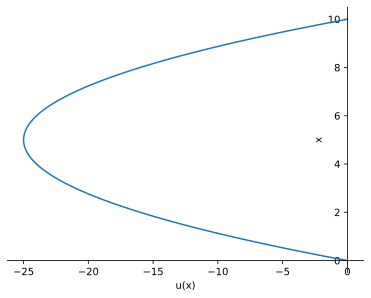

In [4]:
%matplotlib inline
u_trial_func = sym.lambdify(x, u_trial.subs(sol).subs(c,1).subs(L,5))
x_plot = np.linspace(0, 10,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{solution-end}
```

```{exercise-start} epsilon
:label: exercise_2_5
:nonumber: true

For the strain energy we needed the strain distribution instead of the displacement. The strain is the derivative of the displacement, which can be found with SymPy:

For this exercise you just have to run the cell below.
```


In [ ]:
epsilon_trial = sym.diff(u_trial,x)
display(epsilon_trial)

```{exercise-end}
```

```{solution-start} exercise_2_5
:class: dropdown
```

In [6]:
epsilon_trial = sym.diff(u_trial,x)
display(epsilon_trial)

-2*L*c + 2*c*x

```{solution-end}
```

```{exercise-start} strain energy
:label: exercise_3
:nonumber: true

Now let's evaluate the strain energy:
```

In [ ]:
E_v_trial = sym.integrate(#term to integrate,(x,#integrate from, #integrate to)) + ...
display(E_v_trial)

```{exercise-end}
```

```{solution-start} exercise_3
:class: dropdown
```

The answer should be $2 \ EA \ L^3 c^2$

In [7]:
E_v_trial = sym.integrate(EA*epsilon_trial**2/2,(x,0,L))+sym.integrate(EA*2*epsilon_trial**2/2,(x,L,2*L))
display(E_v_trial)

2*EA*L**3*c**2

```{solution-end}
```

```{exercise} Work by force
:label: exercise_4
:nonumber: true

What's the work done by the force $F$?
```

```{solution} exercise_4
:class: dropdown

$$- F \cdot u(L)$$

```

```{exercise-start} Potential energy
:label: exercise_5
:nonumber: true

Find the relation for the potential energy.
```

In [ ]:
V = #expression for V
display(V)

```{exercise-end}
```

```{solution-start} exercise_5
:class: dropdown
```

The answer should be $2 EA \ L^3 c^2 - F\ L^2 c$

In [8]:
V = E_v_trial - ( -F * u_trial.subs(x,L))
display(V)

2*EA*L**3*c**2 - F*L**2*c

```{solution-end}
```

```{exercise-start} Stationary strain energy
:label: exercise_6
:nonumber: true

Now, let's impose the stationary condition for the strain energy in an equation which we can use to solve for the unknown $c$.
```

In [ ]:
eq3 = sym.Eq(#left hand side of equation, #right hand side of equation)
display(eq3)
c_sol = sym.solve(eq3,c)[0]
display(c_sol)
u_trial_sol = u_trial.subs(c,c_sol)
display(u_trial_sol)

Let's check your solution graphically for a value of $5$ m for $L$, $2000$ kN for $EA$ and $30$ kN for $F$:

In [ ]:
%matplotlib inline
L_test = 5
EA_test = 2000
F_test = 30
u_trial_func = sym.lambdify(x, u_trial_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot = np.linspace(0, L_test*2,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_6
:class: dropdown
```

The answer should be $-\cfrac{F \ x}{2 \ EA} + \cfrac{ F \ x^2}{4 \ EA \ L}$

In [9]:
eq3 = sym.Eq(V.diff(c),0)
display(eq3)
c_sol = sym.solve(eq3,c)[0]
display(c_sol)
u_trial_sol = u_trial.subs(c,c_sol)
display(u_trial_sol)

Eq(4*EA*L**3*c - F*L**2, 0)

F/(4*EA*L)

-F*x/(2*EA) + F*x**2/(4*EA*L)

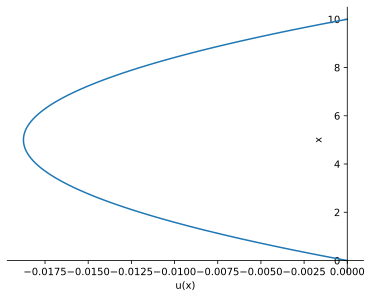

In [10]:
%matplotlib inline
L_test = 5
EA_test = 2000
F_test = 30
u_trial_func = sym.lambdify(x, u_trial_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot = np.linspace(0, L_test*2,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{solution-end}
```

```{exercise-start} Normal force
:label: exercise_6_5
:nonumber: true

What is the normal force distribution?
```

In [ ]:
epsilon = #...

N_trial_sol_AC = #
N_trial_sol_BC = #

display(N_trial_sol_AC.simplify())
display(N_trial_sol_BC.simplify())

Let's check your solution graphically for a value of $5$ m for $L$, $2000$ kN for $EA$ and $30$ kN for $F$:

In [ ]:
%matplotlib inline
L_test = 5
EA_test = 2000
F_test = 30
fig, ax = plt.subplots()

N_trial_func_AC = sym.lambdify(x, N_trial_sol_AC.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
N_trial_func_BC = sym.lambdify(x, N_trial_sol_BC.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,2)
x_plot_BC = np.linspace(L_test, L_test*2,2)
ax.plot(N_trial_func_AC(x_plot_AC),x_plot_AC)
ax.plot(N_trial_func_BC(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('N(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_6_5
:class: dropdown
```

You should have found:

- $N_{\text{AC,trial}}\left(x\right) = \cfrac{F \ \left(-L + x\right)}{2 \ L}$
- $N_{\text{BC,trial}}\left(x\right) = \cfrac{F \ \left(-L + x\right)}{L}$

In [11]:
epsilon = sym.diff(u_trial_sol,x)

N_trial_sol_AC = EA * epsilon
N_trial_sol_BC = 2 * EA * epsilon

display(N_trial_sol_AC.simplify())
display(N_trial_sol_BC.simplify())

F*(-L + x)/(2*L)

F*(-L + x)/L

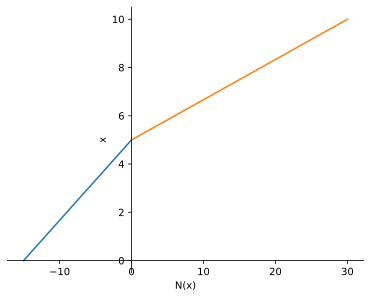

In [13]:
%matplotlib inline
L_test = 5
EA_test = 2000
F_test = 30
fig, ax = plt.subplots()

N_trial_func_AC = sym.lambdify(x, N_trial_sol_AC.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
N_trial_func_BC = sym.lambdify(x, N_trial_sol_BC.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,2)
x_plot_BC = np.linspace(L_test, L_test*2,2)
ax.plot(N_trial_func_AC(x_plot_AC),x_plot_AC)
ax.plot(N_trial_func_BC(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('N(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{solution-end}
```

## Solve with differential equation

Now, let's solve the same structure using the differential equation.

```{exercise-start} Generalised relations
:label: exercise_7
:nonumber: true

```
Given a load $q=0$, integrate twice to find the normal force, strain and displacement relations with integration constants:

In [ ]:
C_1, C_2, C_3, C_4 = sym.symbols('C_1, C_2, C_3, C_4')

q_AC = 0
q_BC = 0

N_AC = C_1 + sym.integrate(#..., x)
N_BC = C_3 + #...

display(N_AC)
display(N_BC)

epsilon_AC = #...
epsilon_BC = #...

display(epsilon_AC)
display(epsilon_BC)

u_AC = C_2 + #...
u_BC = C_3 + #...

display(u_AC)
display(u_BC)

```{exercise-end}
```

```{solution-start} exercise_7
:class: dropdown
```

You should have found:

- $N_{\text{AC}} = C_1$
- $N_{\text{BC}} = C_3$
- $\epsilon_{\text{AC}} = \cfrac{C_1}{EA}$
- $\epsilon_{\text{BC}} = \cfrac{C_3}{2 \ EA}$
- $u_{\text{AC}} = \cfrac{C_1}{EA} x + C_2$
- $u_{\text{BC}} = \cfrac{C_3}{2 \ EA} x + C_4$

In [15]:
C_1, C_2, C_3, C_4 = sym.symbols('C_1, C_2, C_3, C_4')

q_AC = 0
q_BC = 0

N_AC = C_1 + sym.integrate(q_AC, x)
N_BC = C_3 + sym.integrate(q_BC, x)

display(N_AC)
display(N_BC)

epsilon_AC = N_AC / EA
epsilon_BC = N_BC / EA / 2

display(epsilon_AC)
display(epsilon_BC)

u_AC = C_2 + sym.integrate(epsilon_AC, x)
u_BC = C_4 + sym.integrate(epsilon_BC, x)

display(u_AC)
display(u_BC)

C_1

C_3

C_1/EA

C_3/(2*EA)

C_1*x/EA + C_2

C_3*x/(2*EA) + C_4

```{solution-end}
```

```{exercise} Boundary conditions
:label: exercise_8
:nonumber: true

What are the boundary conditions?
```

```{solution} exercise_8
:class: dropdown

- $u_\text{AC} \left(0\right)=0$
- $u_\text{AC} \left(L\right)=u_\text{BC} \left(L\right)$
- $u_\text{BC} \left(2 \ L \right) = 0$
- $N_\text{AC} \left(L\right) + F = N_\text{BC} \left( L\right)$
```

```{exercise-start} Solve boundary conditions
:label: exercise_9
:nonumber: true

Now, let's use SymPy to solve for the boundary conditions using `sym.solve` similarly as you did in [the exercise for the kinematical admissibility trial function](exercise_2) and find the solution for $u_\text{AC}$, $u_\text{BC}, $N_\text{AC}$ and $N_\text{BC}
```

In [ ]:
eq4 = #...
#...

C_sol = sym.solve((eq4,#...),[#])
display(sol)

u_AC_sol = u_AC.subs(C_sol)
u_BC_sol = u_BC.subs(C_sol)
display(u_AC_sol)
display(u_BC_sol)
N_AC_sol = #
N_BC_sol = #
display(N_AC_sol)
display(N_BC_sol)

Let's check your solution graphically for a value of $5$ m for $L$, $2000$ kN for $EA$ and $30$ kN for $F$:

In [ ]:
%matplotlib inline
u_AC_func = sym.lambdify(x, u_AC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
u_BC_func = sym.lambdify(x, u_BC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,100)
x_plot_BC = np.linspace(L_test, L_test*2,100)
fig, ax = plt.subplots()
ax.plot(u_AC_func(x_plot_AC),x_plot_AC)
ax.plot(u_BC_func(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

In [ ]:
N_AC_func = sym.lambdify(x, N_AC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
N_BC_func = sym.lambdify(x, N_BC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,2)
x_plot_BC = np.linspace(L_test, L_test*2,2)
fig, ax = plt.subplots()
ax.plot(N_AC_func(x_plot_AC)*np.ones(2),x_plot_AC)
ax.plot(N_BC_func(x_plot_BC)*np.ones(2),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

```{exercise-end}
```

```{solution-start} exercise_7
:class: dropdown
```

You should find:
- $u_\text{AC} = -\cfrac{F \ x}{3 \ EA}$
- $u_\text{BC} = -\cfrac{2 \ F \ L}{3 \ EA} + \cfrac{F \ x}{3 \ EA}$
- $N_\text{AC} = -\cfrac{F}{3}$
- $N_\text{BC} = -\cfrac{2 \ F }{3}$


In [16]:
eq4 = sym.Eq(u_AC.subs(x,0), 0)
eq5 = sym.Eq(u_AC.subs(x,L), u_BC.subs(x,L))
eq6 = sym.Eq(u_BC.subs(x,2*L), 0)
eq7 = sym.Eq(N_AC.subs(x,L)+F, N_BC.subs(x,L))

display(eq4)
display(eq5)
display(eq6)
display(eq7)

C_sol = sym.solve((eq4,eq5,eq6,eq7),(C_1,C_2,C_3,C_4))
display(C_sol)

u_AC_sol = u_AC.subs(C_sol)
u_BC_sol = u_BC.subs(C_sol)
display(u_AC_sol)
display(u_BC_sol)
N_AC_sol = N_AC.subs(C_sol)
N_BC_sol = N_BC.subs(C_sol)
display(N_AC_sol)
display(N_BC_sol)


Eq(C_2, 0)

Eq(C_1*L/EA + C_2, C_3*L/(2*EA) + C_4)

Eq(C_3*L/EA + C_4, 0)

Eq(C_1 + F, C_3)

{C_1: -F/3, C_2: 0, C_3: 2*F/3, C_4: -2*F*L/(3*EA)}

-F*x/(3*EA)

-2*F*L/(3*EA) + F*x/(3*EA)

-F/3

2*F/3

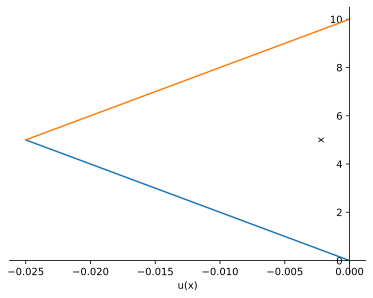

In [17]:
%matplotlib inline
u_AC_func = sym.lambdify(x, u_AC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
u_BC_func = sym.lambdify(x, u_BC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,100)
x_plot_BC = np.linspace(L_test, L_test*2,100)
fig, ax = plt.subplots()
ax.plot(u_AC_func(x_plot_AC),x_plot_AC)
ax.plot(u_BC_func(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


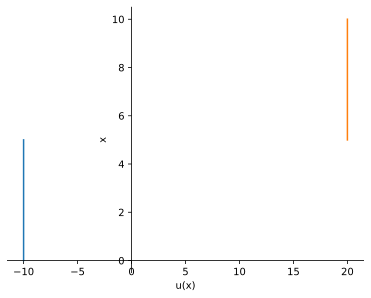

In [18]:
N_AC_func = sym.lambdify(x, N_AC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
N_BC_func = sym.lambdify(x, N_BC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
x_plot_AC = np.linspace(0, L_test,2)
x_plot_BC = np.linspace(L_test, L_test*2,2)
fig, ax = plt.subplots()
ax.plot(N_AC_func(x_plot_AC)*np.ones(2),x_plot_AC)
ax.plot(N_BC_func(x_plot_BC)*np.ones(2),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

```{solution-end}
```

# Comparison

Now, let's compare the plots of both solution strategies, you can try different values:

In [19]:
from ipywidgets import widgets, interact

In [ ]:
%matplotlib widget

fig, ax = plt.subplots()
fig.canvas.toolbar_visible = False
def func(L_test, EA_test, F_test):
    ax.clear()
    u_trial_func = sym.lambdify(x, u_trial_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    u_AC_func = sym.lambdify(x, u_AC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    u_BC_func = sym.lambdify(x, u_BC_sol.subs(sol).subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    x_plot = np.linspace(0, L_test*2,100)
    x_plot_AC = np.linspace(0, L_test,2)
    x_plot_BC = np.linspace(L_test, L_test*2,2)
    ax.plot(u_AC_func(x_plot_AC),x_plot_AC,label='u_AC ODE')
    ax.plot(u_BC_func(x_plot_BC),x_plot_BC, label='u_BC ODE')
    ax.plot(u_trial_func(x_plot),x_plot, label='u trial')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.set_xlabel('u(x)')
    ax.set_ylabel('x')
    ax.legend(loc='best')
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

interact(func, L_test = widgets.FloatSlider(min=0.1, max=5, value=2, step=0.1, description="Length (m)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}),
         EA_test = widgets.FloatSlider(min=1000, max=10000, value=2000, step=100, description="EA (kN)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}),
         F_test = widgets.FloatSlider(min=10, max=100, value=30, step=1, description="Force (kN)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}) );

In [ ]:
%matplotlib widget
fig, ax = plt.subplots()
fig.canvas.toolbar_visible = False

def func(L_test, EA_test, F_test):
    ax.clear()
    N_trial_func_AC = sym.lambdify(x, N_trial_sol_AC.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    N_trial_func_BC = sym.lambdify(x, N_trial_sol_BC.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    N_AC_func = sym.lambdify(x, N_AC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    N_BC_func = sym.lambdify(x, N_BC_sol.subs(L,L_test).subs(EA,EA_test).subs(F,F_test))
    x_plot = np.linspace(0, L_test*2,2)
    x_plot_AC = np.linspace(0, L_test,2)
    x_plot_BC = np.linspace(L_test, L_test*2,2)
    ax.plot(N_AC_func(x_plot_AC)*np.ones(2),x_plot_AC,label='u_AC ODE')
    ax.plot(N_BC_func(x_plot_BC)*np.ones(2),x_plot_BC, label='u_BC ODE')
    ax.plot(N_trial_func_AC(x_plot_AC),x_plot_AC, label='u_AC trial')
    ax.plot(N_trial_func_BC(x_plot_BC),x_plot_BC, label='u_BC trial')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.set_xlabel('N(x)')
    ax.set_ylabel('x')
    ax.legend(loc='best')
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

interact(func, L_test = widgets.FloatSlider(min=0.1, max=5, value=2, step=0.1, description="Length (m)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}),
         EA_test = widgets.FloatSlider(min=1000, max=10000, value=2000, step=100, description="EA (kN)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}),
         F_test = widgets.FloatSlider(min=10, max=100, value=30, step=1, description="Force (kN)",readout_format='.1f',style= {'description_width': '200px'},layout = {'width': '450px'}) );

```{exercise} Comparison
:label: exercise_10
:nonumber: true

Would you consider the trial function solution for proper estimates for displacements? How about normal forces?
```

```{solution} exercise_10
:class: dropdown

The estimation for displacement seems okayish, but the difference with the 'real' solution for normal force distribution is much bigger so it might not be advised to use that.

```